## Chunk Size Calculation

In [ ]:
!pip install -U langchain langchain-community langchain-text-splitters pypdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.3/114.3 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.8/338.8 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 70.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.3/234.3 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 5.9 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: langchain-core
    Found

In [ ]:
import os
import matplotlib.pyplot as plt
from langchain_community.document_loaders import PyPDFLoader # open and read PDF files
from langchain_text_splitters import RecursiveCharacterTextSplitter # engine used for Chunking

In [ ]:
# The folder where we saved the downloaded PDFs
PDF_FOLDER = "/content/guidlines"

In [ ]:
def analyze_medical_data_paragraphs(folder_path):
    all_paragraph_lengths = []

    # Find all PDFs in the folder
    files = [f for f in os.listdir(folder_path) if f.endswith('.pdf')]

    if not files:
        print(f"No PDFs found in the '{folder_path}' folder.")
        return

    print(f"Analyzing {len(files)} medical guidelines (Naive Paragraph Method)...")

    for file in files:
        file_path = os.path.join(folder_path, file)
        try:
            # Load the PDF
            loader = PyPDFLoader(file_path)
            pages = loader.load()

            # Combine all text from all pages
            raw_text = ""
            for page in pages:
                raw_text += page.page_content + "\n"

            # Try to split by double newlines (standard paragraph break)
            paragraphs = [p.strip() for p in raw_text.split("\n\n")]

            # Filter out tiny fragments (like single page numbers or broken headers)
            # We only want to see the lengths of actual blocks of text
            valid_paragraphs = [p for p in paragraphs if len(p) > 40]

            # Count the characters in each paragraph
            lengths = [len(p) for p in valid_paragraphs]
            all_paragraph_lengths.extend(lengths)
            print(f"   {file}: Extracted {len(valid_paragraphs)} text blocks.")

        except Exception as e:
            print(f"   Error processing {file}: {e}")

    # --- Generate the Histogram ---
    plt.figure(figsize=(12, 7))

    # We don't restrict the range here because we WANT to see how wild and broken
    # the paragraph lengths are (some might be 5,000+ characters due to missing \n\n)
    plt.hist(all_paragraph_lengths, bins=60, color='#34495e', edgecolor='white', alpha=0.8)

    plt.title("Data Understanding: Naive Paragraph Length Distribution (RAW PDFs)", fontsize=14)
    plt.xlabel("Length of 'Paragraph' (Number of Characters)", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)

    if all_paragraph_lengths:
        avg_len = sum(all_paragraph_lengths) / len(all_paragraph_lengths)
        plt.axvline(avg_len, color='#e74c3c', linestyle='dashed', linewidth=2,
                    label=f'Average Length: {int(avg_len)} chars')
        plt.legend()

    plt.grid(axis='y', alpha=0.2)
    plt.savefig("medical_paragraph_histogram_FAILED.png")

    print(f"\n--- THESIS RESULTS (NAIVE PARAGRAPH METHOD) ---")
    print(f"Total 'Paragraphs' Found: {len(all_paragraph_lengths)}")
    print(f"Average Length: {int(avg_len)} characters.")



Analyzing 10 medical guidelines (Naive Paragraph Method)...
   khk-vers7-0.pdf: Extracted 1 text blocks.
   asthma-vers5-lang.pdf: Extracted 1 text blocks.
   herzinsuffizienz-vers4-0.pdf: Extracted 1 text blocks.
   diabetes-vers3-0.pdf: Extracted 1 text blocks.
   depression-vers3-2-lang.pdf: Extracted 1 text blocks.
   copd-2aufl-vers1.pdf: Extracted 1 text blocks.
   187-050l_S3_Gonarthrose_2025-05.pdf: Extracted 1 text blocks.
   kreuzschmerz-2aufl-vers1-lang-1.pdf: Extracted 1 text blocks.
   hypertonie-vers1-0.pdf: Extracted 1 text blocks.
   2025-02_053-048l_S3_Versorgung-PatientInnen-chronische-nicht-nierenersatz-therpapiepflichtige-Nierenkrankheit-Hausarztpraxis_01.pdf: Extracted 1 text blocks.

--- THESIS RESULTS (NAIVE PARAGRAPH METHOD) ---
Total 'Paragraphs' Found: 10
Average Length: 604860 characters.


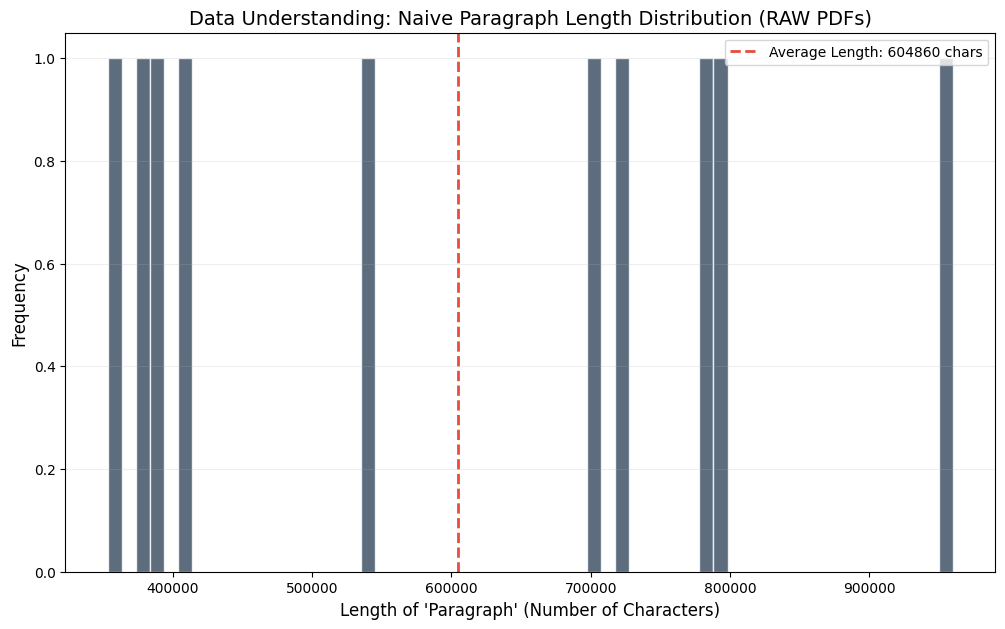

In [ ]:
# Run the function
analyze_medical_data_paragraphs(PDF_FOLDER)

### Why did this fail?

PDFs lack semantic HTML-style paragraph tags. PyPDFLoader relies on hidden \n characters, which in complex medical PDFs do not represent actual paragraph breaks, leading to massive, artificial data chunks.

Initial EDA revealed that PyPDFLoader could not detect semantic paragraph breaks due to the complex typesetting of the NVL guidelines, resulting in chunks around 600,000 characters. To resolve this, a regex-based sentence tokenizer was applied to clean the text, allowing for an accurate calculation of the underlying data distribution.

In [ ]:
import re
def analyze_medical_data_sentences(folder_path):
    all_sentence_lengths = []

    # Find all PDFs in the folder
    files = [f for f in os.listdir(folder_path) if f.endswith('.pdf')]

    if not files:
        print(f"No PDFs found in the '{folder_path}' folder.")
        return

    print(f"Analyzing {len(files)} medical guidelines (7-Sentence Method)...")

    for file in files:
        file_path = os.path.join(folder_path, file)
        try:
            # Load the PDF
            loader = PyPDFLoader(file_path)
            pages = loader.load()

            # Combine all text from all pages
            raw_text = ""
            for page in pages:
                # Use a space instead of \n so we don't accidentally break sentences!
                raw_text += page.page_content + " "

            # THE SMART SPLIT: Split the text into Sentences (looking for periods, question marks, exclamation points)
            # This regex splits when it sees punctuation followed by one or more whitespace characters
            sentences = re.split(r'(?<=[.!?])\s+', raw_text)

            # Filter out junk (Keep chunks of text > 20 characters to avoid counting bullet points, single words, or page numbers)
            valid_sentences = [s.strip() for s in sentences if len(s.strip()) > 20]

            # Count the characters in each sentence
            lengths = [len(s) for s in valid_sentences]
            all_sentence_lengths.extend(lengths)
            print(f"   {file}: Extracted {len(valid_sentences)} valid sentences.")

        except Exception as e:
            print(f"   Error processing {file}: {e}")

    # --- Generate the Histogram ---
    plt.figure(figsize=(12, 7))

    # We set a range up to 500 to keep the graph zoomed in on the meaningful data
    plt.hist(all_sentence_lengths, bins=60, range=(0, 500), color='#27ae60', edgecolor='white', alpha=0.8)

    plt.title("Data Understanding: RAW Sentence Length Distribution", fontsize=14)
    plt.xlabel("Length of Sentence (Number of Characters)", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)

    # Calculate averages and the 7-Sentence Rule
    avg_len = 0
    chunk_size = 0
    overlap = 0

    if all_sentence_lengths:
        avg_len = sum(all_sentence_lengths) / len(all_sentence_lengths)

        # --- MATH ---
        chunk_size = int(avg_len * 7)
        overlap = int(avg_len * 1.5)

        plt.axvline(avg_len, color='#c0392b', linestyle='dashed', linewidth=2,
                    label=f'Average Length: {int(avg_len)} chars')
        plt.legend()

    plt.grid(axis='y', alpha=0.2)
    plt.savefig("medical_sentence_histogram_RAW.png")

    print(f"\n--- THESIS RESULTS (7-SENTENCE METHOD) ---")
    print(f"Total Sentences Analyzed: {len(all_sentence_lengths)}")
    print(f"Average Sentence Length: {int(avg_len)} characters.") # ~ exactly 131.86 characters but with int function we print 131
    print(f"CHUNK SIZE (7 Sentences): {chunk_size} characters.")
    print(f"OVERLAP (1.5 Sentences): {overlap} characters.")



Analyzing 10 medical guidelines (7-Sentence Method)...
   khk-vers7-0.pdf: Extracted 5552 valid sentences.
   asthma-vers5-lang.pdf: Extracted 5314 valid sentences.
   herzinsuffizienz-vers4-0.pdf: Extracted 6350 valid sentences.
   diabetes-vers3-0.pdf: Extracted 3718 valid sentences.
   depression-vers3-2-lang.pdf: Extracted 6865 valid sentences.
   copd-2aufl-vers1.pdf: Extracted 2976 valid sentences.
   187-050l_S3_Gonarthrose_2025-05.pdf: Extracted 5338 valid sentences.
   kreuzschmerz-2aufl-vers1-lang-1.pdf: Extracted 3342 valid sentences.
   hypertonie-vers1-0.pdf: Extracted 3040 valid sentences.
   2025-02_053-048l_S3_Versorgung-PatientInnen-chronische-nicht-nierenersatz-therpapiepflichtige-Nierenkrankheit-Hausarztpraxis_01.pdf: Extracted 2361 valid sentences.

--- THESIS RESULTS (7-SENTENCE METHOD) ---
Total Sentences Analyzed: 44856
Average Sentence Length: 131 characters.
CHUNK SIZE (7 Sentences): 923 characters.
OVERLAP (1.5 Sentences): 197 characters.


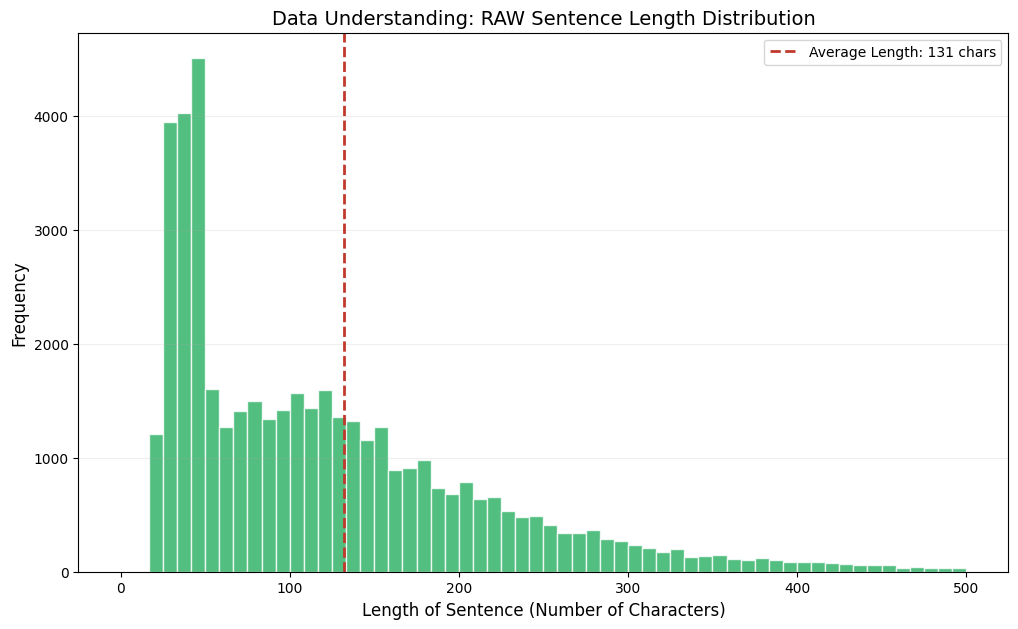

In [ ]:
# Run the function
analyze_medical_data_sentences(PDF_FOLDER)

We can round the overlap size to 200
Chunk size is 923

## Process and Chunk PDFs

In [ ]:
def process_and_chunk_pdfs(folder_path):
    all_pages = []

    # 1. Find and load all PDFs
    files = [f for f in os.listdir(folder_path) if f.endswith('.pdf')]
    print(f"Loading {len(files)} medical guidelines...")

    for file in files:
        try:
            loader = PyPDFLoader(os.path.join(folder_path, file))
            pages = loader.load()
            all_pages.extend(pages)
        except Exception as e:
            print(f"Error loading {file}: {e}")

    print(f"Successfully loaded {len(all_pages)} total PDF pages.")

    # 2. THE SPLITTER: Use the  mathematically proven numbers!
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=923,        # The 7-Sentence Rule Baseline
        chunk_overlap=200,     # The 1.5-Sentence Overlap
        separators=["\n\n", "\n", ".", " ", ""] # Respect sentence boundaries
    )

    # 3. Cut the pages into semantic chunks
    print("Chunking documents based on Phase 1 parameters...")
    medical_chunks = text_splitter.split_documents(all_pages)

    print(f"Success! Created {len(medical_chunks)} medical knowledge chunks ready for the database.")

    # Optional: Print the first chunk just to verify it looks good
    if medical_chunks:
        print("\n--- SAMPLE CHUNK ---")
        print(medical_chunks[0].page_content)
        print("--------------------")

    return medical_chunks

In [ ]:
medical_chunks = process_and_chunk_pdfs(PDF_FOLDER)

Loading 10 medical guidelines...
Successfully loaded 1805 total PDF pages.
Chunking documents based on Phase 1 parameters...
Success! Created 8692 medical knowledge chunks ready for the database.

--- SAMPLE CHUNK ---
Träger: 
Bundesärztekammer 
Kassenärztliche Bundesvereinigung 
Arbeitsgemeinschaft der Wissenschaftlichen  
Medizinischen Fachgesellschaften 
  
 
© 2024 NVL-Programm 
Nationale VersorgungsLeitlinie  
Chronische KHK 
 
Langfassung 
 
Version 7.0 
AWMF-Register-Nr. nvl-004
--------------------


Now we will move to the Embedders Testing phase so that we can choose which embadder to use

In [ ]:
!pip install -U langchain-postgres psycopg2-binary langchain-mistralai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 70.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 105.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.0/213.0 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 113.4 MB/s eta 0:00:00


## We move to Data Ingestion

# 1. Generalist Embedding Models

### 1.1. Mistral Embedding model

In [ ]:
import os
import hashlib
from google.colab import userdata
from langchain_mistralai import MistralAIEmbeddings
from langchain_postgres.vectorstores import PGVector

# 1. Load keys
os.environ["MISTRAL_API_KEY"] = userdata.get('MISTRAL_API_KEY')
CONNECTION_STRING = userdata.get('NEON_DATABASE_URL')

print("Connecting to Mistral and Neon Database...")

# 2. Initialize the Mistral Embedding Model
mistral_embedder = MistralAIEmbeddings(model="mistral-embed")

# 3. Define the Database Table (Collection)
collection_name = "awmf_baseline_mistral"

# 4. Connect to Neon and create the Vector Store
vector_store = PGVector(
    embeddings=mistral_embedder,
    collection_name=collection_name,
    connection=CONNECTION_STRING,
    use_jsonb=True, # Highly recommended for Neon/Postgres for faster metadata filtering
)

print(f"Successfully connected to the '{collection_name}' table in Neon!")

# ---------------------------------------------------------
# THE UPLOAD PHASE
# (Assuming 'medical_chunks' is currently in memory)
# ---------------------------------------------------------

# Generate deterministic IDs using MD5 cryptographic hashing
# This ensures zero duplicates during consecutive ingestions
chunk_ids = []
for chunk in medical_chunks:
    fingerprint = hashlib.md5(chunk.page_content.encode('utf-8')).hexdigest()
    chunk_ids.append(fingerprint)

try:
    print(f"Beginning upload of {len(medical_chunks)} chunks to Neon with deterministic IDs...")

    # Push the chunks to the database
    # The embedder will automatically vectorize them on the fly
    vector_store.add_documents(documents=medical_chunks, ids=chunk_ids)

    print("Upload Complete! The Mistral-Embed baseline table is officially ready.")

except NameError:
    print("Error: 'medical_chunks' not found. Ensure the text_splitter script is executed first.")
except Exception as e:
    print(f"Upload failed: {e}")

Connecting to Mistral and Neon Database...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer.json: 0.00B [00:00, ?B/s]

Successfully connected to the 'awmf_baseline_mistral' table in Neon!
Beginning upload of 8692 chunks to Neon with deterministic IDs...
Upload failed: (psycopg2.errors.CardinalityViolation) ON CONFLICT DO UPDATE command cannot affect row a second time
HINT:  Ensure that no rows proposed for insertion within the same command have duplicate constrained values.

[SQL: INSERT INTO langchain_pg_embedding (id, collection_id, embedding, document, cmetadata) VALUES (%(id_m0)s, %(collection_id_m0)s::UUID, %(embedding_m0)s, %(document_m0)s, %(cmetadata_m0)s::JSONB), (%(id_m1)s, %(collection_id_m1)s::UUID, %(embedding_m1)s, %(document_m1)s, %(cmetadata_m1)s::JSONB), (%(id_m2)s, %(collection_id_m2)s::UUID, %(embedding_m2)s, %(document_m2)s, %(cmetadata_m2)s::JSONB), (%(id_m3)s, %(collection_id_m3)s::UUID, %(embedding_m3)s, %(document_m3)s, %(cmetadata_m3)s::JSONB), (%(id_m4)s, %(collection_id_m4)s::UUID, %(embedding_m4)s, %(document_m4)s, %(cmetadata_m4)s::JSONB), (%(id_m5)s, %(collection_id_m5)s::

In [ ]:
!pip install -U langchain-cohere

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.0/43.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 334.3/334.3 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 91.4 MB/s eta 0:00:00


### 1.2. Cohere Embedding model

In [ ]:
import time
import hashlib
from google.colab import userdata
from langchain_cohere import CohereEmbeddings
from langchain_postgres.vectorstores import PGVector

# 1. Load keys explicitly from Colab Secrets
CONNECTION_STRING = userdata.get('NEON_DATABASE_URL')
COHERE_KEY = userdata.get('COHERE_API_KEY')

print("Initializing Cohere embed-multilingual-v3.0 (Rate-Limit Safe Mode)...")

# 2. Initialize the embedder
cohere_embedder = CohereEmbeddings(
    cohere_api_key=COHERE_KEY,
    model="embed-multilingual-v3.0",
    user_agent="eval_pipeline"
)

collection_cohere = "awmf_baseline_cohere"

# 3. Connect to Neon
vector_store_cohere = PGVector(
    embeddings=cohere_embedder,
    collection_name=collection_cohere,
    connection=CONNECTION_STRING,
    use_jsonb=True,
)

# 4. Generate deterministic IDs using MD5 cryptographic hashing
# This ensures zero duplicates during consecutive ingestions
chunk_ids = []
for chunk in medical_chunks:
    fingerprint = hashlib.md5(chunk.page_content.encode('utf-8')).hexdigest()
    chunk_ids.append(fingerprint)

# --- BATCHING TO PREVENT RATE LIMIT ERRORS ---
batch_size = 90  # Send 90 chunks at a time
pause_time = 60  # Wait 60 seconds between batches

print(f"Starting Cohere upload in batches of {batch_size} with deterministic IDs...")

try:
    for i in range(0, len(medical_chunks), batch_size):
        # Extract the current batch of chunks and their corresponding IDs
        batch = medical_chunks[i:i + batch_size]
        batch_ids = chunk_ids[i:i + batch_size]

        print(f"  -> Uploading chunks {i} to {i + len(batch)}...")

        # Upload the batch
        vector_store_cohere.add_documents(documents=batch, ids=batch_ids)

        # Pause execution to respect API rate limits (skips pause on the final batch)
        if i + batch_size < len(medical_chunks):
            print(f"  -> Sleeping for {pause_time}s to respect API rate limits...")
            time.sleep(pause_time)

    print("Cohere Upload Complete! Rate limit protocol successfully executed.")
except Exception as e:
    print(f"Cohere Upload failed: {e}")

Initializing Cohere embed-multilingual-v3.0 (Rate-Limit Safe Mode)...
Starting Cohere upload in batches of 90 with deterministic IDs...
  -> Uploading chunks 0 to 90...
  -> Sleeping for 60s to respect API rate limits...
  -> Uploading chunks 90 to 180...
  -> Sleeping for 60s to respect API rate limits...
  -> Uploading chunks 180 to 270...
  -> Sleeping for 60s to respect API rate limits...
  -> Uploading chunks 270 to 360...
  -> Sleeping for 60s to respect API rate limits...
  -> Uploading chunks 360 to 450...
  -> Sleeping for 60s to respect API rate limits...
  -> Uploading chunks 450 to 540...
  -> Sleeping for 60s to respect API rate limits...
  -> Uploading chunks 540 to 630...
  -> Sleeping for 60s to respect API rate limits...
  -> Uploading chunks 630 to 720...
  -> Sleeping for 60s to respect API rate limits...
  -> Uploading chunks 720 to 810...
Cohere Upload failed: (psycopg2.errors.CardinalityViolation) ON CONFLICT DO UPDATE command cannot affect row a second time
HINT:

In [ ]:
!pip install -U langchain-huggingface

### 1.3. BGE-M3 Multilingual Model

In [ ]:
import hashlib
from google.colab import userdata
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_postgres.vectorstores import PGVector

CONNECTION_STRING = userdata.get('NEON_DATABASE_URL')

print("Downloading the open-source BGE-M3 Multilingual Model...")

bge_embedder = HuggingFaceEmbeddings(
    model_name="BAAI/bge-m3",
    model_kwargs={'device': 'cuda'}
)

collection_bge = "awmf_baseline_bge"

vector_store_bge = PGVector(
    embeddings=bge_embedder,
    collection_name=collection_bge,
    connection=CONNECTION_STRING,
    use_jsonb=True,
)

# ---------------------------------------------------------
# THE FIX: DEDUPLICATE THE CHUNKS BEFORE UPLOADING
# ---------------------------------------------------------
unique_chunks = []
unique_ids = []
seen_hashes = set()

for chunk in medical_chunks:
    fingerprint = hashlib.md5(chunk.page_content.encode('utf-8')).hexdigest()

    # Only keep the chunk if we haven't seen this exact text before
    if fingerprint not in seen_hashes:
        seen_hashes.add(fingerprint)
        unique_chunks.append(chunk)
        unique_ids.append(fingerprint)

duplicates_removed = len(medical_chunks) - len(unique_chunks)
print(f"Cleaned up {duplicates_removed} duplicate chunks from the dataset!")
print(f"Proceeding to upload the remaining {len(unique_chunks)} unique chunks...")

# ---------------------------------------------------------
# BATCHED UPLOAD
# ---------------------------------------------------------
batch_size = 500

try:
    # Notice we are looping over 'unique_chunks' now, not 'medical_chunks'
    for i in range(0, len(unique_chunks), batch_size):
        batch = unique_chunks[i:i + batch_size]
        batch_ids = unique_ids[i:i + batch_size]

        print(f"  -> Embedding & Uploading chunks {i} to {i + len(batch)}...")

        vector_store_bge.add_documents(documents=batch, ids=batch_ids)

    print("BGE-M3 Upload Complete! Group A is officially finished.")
except Exception as e:
    print(f"Upload failed: {e}")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Cleaned up 5 duplicate chunks from the dataset!
Proceeding to upload the remaining 8687 unique chunks...
  -> Embedding & Uploading chunks 0 to 500...
  -> Embedding & Uploading chunks 500 to 1000...
  -> Embedding & Uploading chunks 1000 to 1500...
  -> Embedding & Uploading chunks 1500 to 2000...
  -> Embedding & Uploading chunks 2000 to 2500...
  -> Embedding & Uploading chunks 2500 to 3000...
  -> Embedding & Uploading chunks 3000 to 3500...
  -> Embedding & Uploading chunks 3500 to 4000...
  -> Embedding & Uploading chunks 4000 to 4500...
  -> Embedding & Uploading chunks 4500 to 5000...
  -> Embedding & Uploading chunks 5000 to 5500...
  -> Embedding & Uploading chunks 5500 to 6000...
  -> Embedding & Uploading chunks 6000 to 6500...
  -> Embedding & Uploading chunks 6500 to 7000...
  -> Embedding & Uploading chunks 7000 to 7500...
  -> Embedding & Uploading chunks 7500 to 8000...
  -> Embedding & Uploading chunks 8000 to 8500...
  -> Embedding & Uploading chunks 8500 to 8687...


# 2. Domain Specific Embedding Model

### 2.1. PubMedBERT

In [ ]:
import hashlib
from google.colab import userdata
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_postgres.vectorstores import PGVector

CONNECTION_STRING = userdata.get('NEON_DATABASE_URL')

print("Downloading PubMedBERT (Domain-Specific Medical Model)...")

# 1. Initialize the Medical Embedder locally on GPU
medical_embedder = HuggingFaceEmbeddings(
    model_name="NeuML/pubmedbert-base-embeddings",
    model_kwargs={'device': 'cuda'}
)

collection_medical = "awmf_baseline_pubmedbert"

# 2. Connect to Neon
vector_store_medical = PGVector(
    embeddings=medical_embedder,
    collection_name=collection_medical,
    connection=CONNECTION_STRING,
    use_jsonb=True,
)

# ---------------------------------------------------------
# 3. DEDUPLICATE THE CHUNKS BEFORE UPLOADING
# ---------------------------------------------------------
unique_chunks = []
unique_ids = []
seen_hashes = set()

for chunk in medical_chunks:
    fingerprint = hashlib.md5(chunk.page_content.encode('utf-8')).hexdigest()

    if fingerprint not in seen_hashes:
        seen_hashes.add(fingerprint)
        unique_chunks.append(chunk)
        unique_ids.append(fingerprint)

duplicates_removed = len(medical_chunks) - len(unique_chunks)
print(f"Cleaned up {duplicates_removed} duplicate chunks from the dataset!")
print(f"Proceeding to upload the remaining {len(unique_chunks)} unique chunks...")

# ---------------------------------------------------------
# 4. BATCHED UPLOAD
# ---------------------------------------------------------
batch_size = 500

try:
    for i in range(0, len(unique_chunks), batch_size):
        batch = unique_chunks[i:i + batch_size]
        batch_ids = unique_ids[i:i + batch_size]

        print(f"  -> Embedding & Uploading chunks {i} to {i + len(batch)}...")

        vector_store_medical.add_documents(documents=batch, ids=batch_ids)

    print("PubMedBERT Upload Complete! The first Medical Specialist is in the database.")
except Exception as e:
    print(f"Upload failed: {e}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Cleaned up 5 duplicate chunks from the dataset!
Proceeding to upload the remaining 8687 unique chunks...
  -> Embedding & Uploading chunks 0 to 500...
  -> Embedding & Uploading chunks 500 to 1000...
  -> Embedding & Uploading chunks 1000 to 1500...
  -> Embedding & Uploading chunks 1500 to 2000...
  -> Embedding & Uploading chunks 2000 to 2500...
  -> Embedding & Uploading chunks 2500 to 3000...
  -> Embedding & Uploading chunks 3000 to 3500...
  -> Embedding & Uploading chunks 3500 to 4000...
  -> Embedding & Uploading chunks 4000 to 4500...
  -> Embedding & Uploading chunks 4500 to 5000...
  -> Embedding & Uploading chunks 5000 to 5500...
  -> Embedding & Uploading chunks 5500 to 6000...
  -> Embedding & Uploading chunks 6000 to 6500...
  -> Embedding & Uploading chunks 6500 to 7000...
  -> Embedding & Uploading chunks 7000 to 7500...
  -> Embedding & Uploading chunks 7500 to 8000...
  -> Embedding & Uploading chunks 8000 to 8500...
  -> Embedding & Uploading chunks 8500 to 8687...


### 2.2. UMLSBERT

In [ ]:
import hashlib
from google.colab import userdata
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_postgres.vectorstores import PGVector

# 1. Load keys
CONNECTION_STRING = userdata.get('NEON_DATABASE_URL')

print("Downloading UMLSBERT (Concept-level Clinical Model)...")

# 2. Initialize the UMLSBERT Embedder locally on GPU
umls_embedder = HuggingFaceEmbeddings(
    model_name="GanjinZero/UMLSBERT",
    model_kwargs={'device': 'cuda'}
)

collection_umls = "awmf_baseline_umlsbert"

# 3. Connect to Neon
vector_store_umls = PGVector(
    embeddings=umls_embedder,
    collection_name=collection_umls,
    connection=CONNECTION_STRING,
    use_jsonb=True,
)

# 4. Generate deterministic IDs using MD5 cryptographic hashing
chunk_ids = []
for chunk in medical_chunks:
    fingerprint = hashlib.md5(chunk.page_content.encode('utf-8')).hexdigest()
    chunk_ids.append(fingerprint)

# 5. Upload the final medical vectors
try:
    print(f"Beginning upload of {len(medical_chunks)} chunks to {collection_umls} with deterministic IDs...")

    vector_store_umls.add_documents(documents=medical_chunks, ids=chunk_ids)

    print("Upload Complete! The UMLSBERT medical table is officially ready.")
except Exception as e:
    print(f"Upload failed: {e}")

OSError: GanjinZero/UMLSBERT is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `hf auth login` or by passing `token=<your_token>`

### 2.3. BioBERT

In [ ]:
import hashlib
from google.colab import userdata
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_postgres.vectorstores import PGVector

CONNECTION_STRING = userdata.get('NEON_DATABASE_URL')

print("Downloading BioBERT (Medical Baseline Model)...")

# 1. Initialize BioBERT locally on GPU
# We use a version specifically fine-tuned for semantic embeddings (sentence-transformers)
biobert_embedder = HuggingFaceEmbeddings(
    model_name="pritamdeka/S-BioBERT-snli-multinli-stsb",
    model_kwargs={'device': 'cuda'}
)

collection_biobert = "awmf_baseline_biobert"

# 2. Connect to Neon
vector_store_biobert = PGVector(
    embeddings=biobert_embedder,
    collection_name=collection_biobert,
    connection=CONNECTION_STRING,
    use_jsonb=True,
)

# 3. Generate deterministic IDs using MD5 cryptographic hashing
chunk_ids = []
for chunk in medical_chunks:
    fingerprint = hashlib.md5(chunk.page_content.encode('utf-8')).hexdigest()
    chunk_ids.append(fingerprint)

# 4. Upload the medical vectors
try:
    print(f"Beginning upload of {len(medical_chunks)} chunks to {collection_biobert} with deterministic IDs...")

    vector_store_biobert.add_documents(documents=medical_chunks, ids=chunk_ids)

    print("Upload Complete! The BioBERT medical table is officially ready.")
except Exception as e:
    print(f"Upload failed: {e}")

## Let's test!

we first install RAGAS framework

In [ ]:
!pip install -U ragas datasets

we use mistral LLM as the Judge for evaluation

In [ ]:
import os
from google.colab import userdata
from datasets import Dataset
from ragas import evaluate
from ragas.metrics import context_precision, context_recall
from langchain_mistralai.chat_models import ChatMistralAI
from langchain_mistralai import MistralAIEmbeddings
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper

# 1. Load ONLY your Mistral key
os.environ["MISTRAL_API_KEY"] = userdata.get('MISTRAL_API_KEY')

print("Configuring RAGAS to use Mistral as the Judge...")

# 2. Initialize the Mistral Generative LLM (The Judge)
mistral_judge_llm = ChatMistralAI(model="mistral-large-latest")

# 3. Initialize the Mistral Embedder (RAGAS sometimes needs an embedder for its own internal math)
mistral_judge_embeddings = MistralAIEmbeddings(model="mistral-embed")

# 4. Wrap them for RAGAS
ragas_llm = LangchainLLMWrapper(mistral_judge_llm)
ragas_embeddings = LangchainEmbeddingsWrapper(mistral_judge_embeddings)

print("✅ RAGAS is successfully configured with Mistral! Zero OpenAI required.")